In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# agar grafik lebih rapi
plt.style.use('default')
sns.set_theme()

In [2]:
df = pd.read_csv("sensor_kualitas_elektronik.csv")

# Menampilkan 10 data pertama
df.head(10)

,ID_Unit,Tegangan_Output_Volt,Arus_Output_Ampere,Suhu_Komponen_Celcius,Waktu_Uji_Detik,Line_Perakitan,Status_Akhir
0,U00001,11.874,2.160,49.2,16.6,L1,Lolos
1,U00002,11.756,2.396,43.5,17.5,L2,Lolos
2,U00003,12.292,1.790,48.5,18.1,L2,Lolos
3,U00004,11.932,1.894,35.0,20.9,L3,Lolos
4,U00005,NaN,2.202,47.9,13.8,L1,Lolos
5,U00006,12.333,2.208,49.5,14.9,L2,Lolos
6,U00007,12.409,2.274,45.9,14.3,L3,Lolos
7,U00008,NaN,2.254,52.0,20.6,L2,Lolos
8,U00009,11.476,1.617,46.7,17.7,L3,Lolos
9,U00010,11.966,1.880,45.9,15.3,L1,Lolos


In [3]:
print("Jumlah baris dan kolom :", df.shape)

Jumlah baris dan kolom : (1800, 7)


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1800 entries, 0 to 1799
Data columns (total 7 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   ID_Unit                1800 non-null   str    
 1   Tegangan_Output_Volt   1692 non-null   float64
 2   Arus_Output_Ampere     1674 non-null   float64
 3   Suhu_Komponen_Celcius  1800 non-null   float64
 4   Waktu_Uji_Detik        1800 non-null   float64
 5   Line_Perakitan         1800 non-null   str    
 6   Status_Akhir           1800 non-null   str    
dtypes: float64(4), str(3)
memory usage: 98.6 KB


In [5]:
df.describe()

,Tegangan_Output_Volt,Arus_Output_Ampere,Suhu_Komponen_Celcius,Waktu_Uji_Detik
count,1692.000000,1674.000000,1800.000000,1800.000000
mean,11.864223,2.055350,45.927667,17.878222
std,0.488638,0.274643,6.688752,3.004420
min,9.750000,1.191000,22.100000,8.600000
25%,11.636000,1.873000,41.300000,15.800000
50%,11.923000,2.036000,45.500000,17.900000
75%,12.193000,2.228000,50.000000,19.900000
max,13.753000,3.049000,76.000000,28.900000


In [6]:
df.describe(include='object')

C:\Users\Azzam\AppData\Local\Temp\ipykernel_1540\87514550.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  df.describe(include='object')


,ID_Unit,Line_Perakitan,Status_Akhir
count,1800,1800,1800
unique,1800,3,2
top,U00001,L1,Lolos
freq,1,610,1565


In [7]:
df.isnull().sum()

ID_Unit                    0
Tegangan_Output_Volt     108
Arus_Output_Ampere       126
Suhu_Komponen_Celcius      0
Waktu_Uji_Detik            0
Line_Perakitan             0
Status_Akhir               0
dtype: int64

In [9]:
status = df['Status_Akhir'].value_counts()

print(status)

print("\nPersentase:")
print(df['Status_Akhir'].value_counts(normalize=True)*100)

Status_Akhir
Lolos    1565
Gagal     235
Name: count, dtype: int64

Persentase:
Status_Akhir
Lolos    86.944444
Gagal    13.055556
Name: proportion, dtype: float64


Berdasarkan hasil inspeksi data menggunakan df.info(), dataset terdiri dari 1800 baris dan 7 kolom, dengan empat atribut numerik dan tiga atribut kategorikal. Hasil pemeriksaan df.isnull().sum() menunjukkan adanya missing value pada kolom Tegangan_Output_Volt sebanyak 108 data dan Arus_Output_Ampere sebanyak 126 data, sedangkan kolom lainnya tidak memiliki nilai kosong. Statistik deskriptif menunjukkan bahwa parameter sensor memiliki rentang nilai yang masih wajar untuk proses pengujian elektronik. Berdasarkan df['Status_Akhir'].value_counts(), terdapat 1565 unit (86,94%) dengan status Lolos dan 235 unit (13,06%) dengan status Gagal, sehingga mayoritas produk berhasil melewati proses pengujian akhir.

In [16]:
df["Tegangan_Output_Volt"] = df["Tegangan_Output_Volt"].fillna(
    df["Tegangan_Output_Volt"].median()
)

df["Arus_Output_Ampere"] = df["Arus_Output_Ampere"].fillna(
    df["Arus_Output_Ampere"].median()
)

In [17]:
df.isnull().sum()

ID_Unit                  0
Tegangan_Output_Volt     0
Arus_Output_Ampere       0
Suhu_Komponen_Celcius    0
Waktu_Uji_Detik          0
Line_Perakitan           0
Status_Akhir             0
dtype: int64

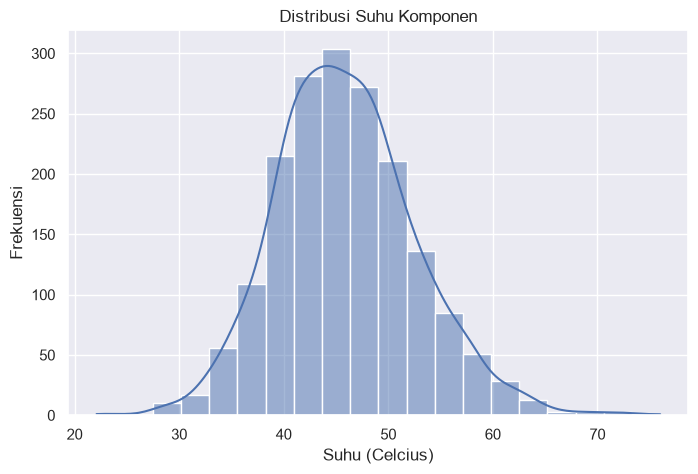

In [18]:
#visualisasi 1
plt.figure(figsize=(8,5))

sns.histplot(df['Suhu_Komponen_Celcius'],
             bins=20,
             kde=True)

plt.title("Distribusi Suhu Komponen")
plt.xlabel("Suhu (Celcius)")
plt.ylabel("Frekuensi")
plt.show()

Histogram menunjukkan distribusi suhu komponen selama proses pengujian. Sebagian besar unit berada pada rentang suhu tertentu sehingga proses pengujian relatif stabil. Jika terdapat sedikit nilai pada suhu yang sangat tinggi atau rendah, hal tersebut dapat menjadi indikasi adanya kondisi operasi yang berbeda dari mayoritas produk.

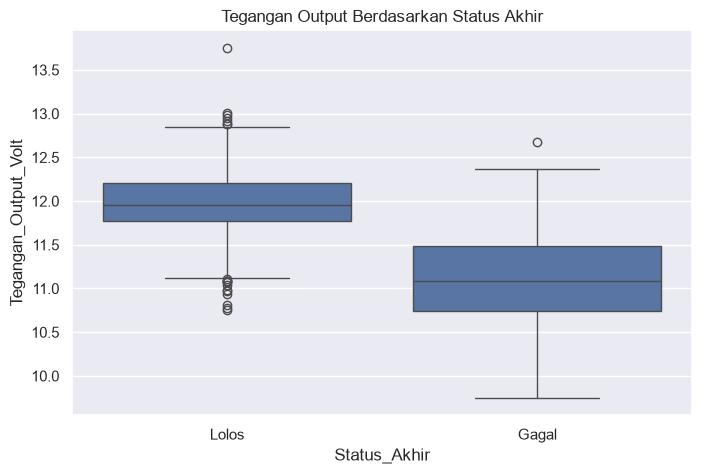

In [19]:
plt.figure(figsize=(8,5))

sns.boxplot(
    x='Status_Akhir',
    y='Tegangan_Output_Volt',
    data=df
)

plt.title("Tegangan Output Berdasarkan Status Akhir")
plt.show()

Boxplot memperlihatkan distribusi tegangan output pada unit yang lolos dan gagal. Apabila median atau penyebaran tegangan pada kelompok gagal berbeda dengan kelompok lolos, maka terdapat indikasi bahwa tegangan output memiliki hubungan dengan keberhasilan pengujian produk.

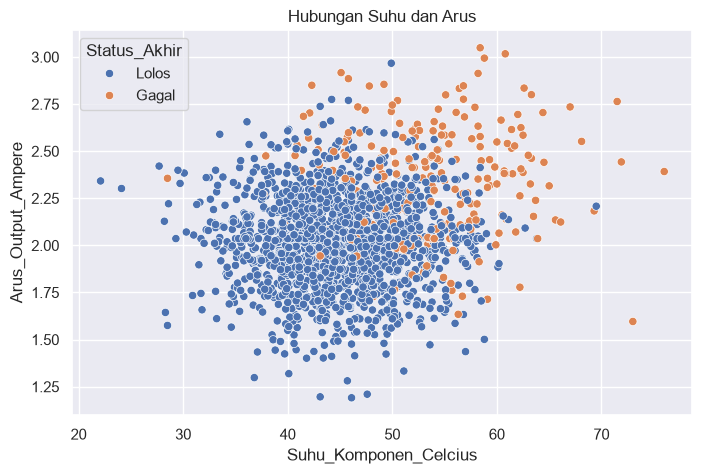

In [20]:
plt.figure(figsize=(8,5))

sns.scatterplot(
    data=df,
    x='Suhu_Komponen_Celcius',
    y='Arus_Output_Ampere',
    hue='Status_Akhir'
)

plt.title("Hubungan Suhu dan Arus")
plt.show()

Scatter plot menunjukkan hubungan antara suhu komponen dan arus output. Apabila titik-titik dengan status gagal cenderung terkonsentrasi pada rentang suhu atau arus tertentu, maka kedua parameter tersebut berpotensi menjadi fitur penting dalam model klasifikasi pada tahap berikutnya.